# Project 01
Energy-Delay Optimization of a Three-Stage CMOS Buffer

In [29]:
# --- 0. IMPORTS AND PATH SETUP ---
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns
from PyLTSpice import SimRunner, SpiceEditor
from PyLTSpice.log.ltsteps import LTSpiceLogReader
import os
from pathlib import Path

# Configure seaborn style
sns.set_style("whitegrid")

# --- 0.1 FILE AND PATH SETUP ---
PROJECT_SIM_FOLDER = Path("../res/srcs/project-01")
OUTPUT_FOLDER = Path("./output/project-01")
OUTPUT_FIG_FOLDER = OUTPUT_FOLDER / "figs"

# Create the output folder if it doesn't exist
if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)

# Create the output fig folder if it doesn't exist
if not os.path.exists(OUTPUT_FIG_FOLDER):
    os.makedirs(OUTPUT_FIG_FOLDER)

# --- 0.2 PROJECT PARAMETERS ---
size_resolution = 5     # PMOS width resolution in nm
Vdd = 1.0               # Supply voltage in V

## Step 01: Minimum inverter sizing

In this step, we simulate the minimum-sized inverter to determine the optimal PMOS width for energy-delay optimization.

This value is calculated by varying the PMOS width from `100nm` to `300nm` with a step of `10nm` and finding at which point the rise and fall delays are equal.

In [30]:
# --- 1. RUN PMOS SIZING SIMULATION ---
# Simulate minimum inverter with varying PMOS width
# Range: 100nm to 300nm, step 10nm

LT_SPICE_PATH = "D:/Softwares/ADI/LTspiceXVII/XVIIx64.exe"

# Initialize simulation runner
runner = SimRunner(output_folder=str(OUTPUT_FOLDER), simulator=LT_SPICE_PATH)

# Load the simulation netlist
netlist = SpiceEditor(PROJECT_SIM_FOLDER / "01-PMOS_sizing" / "inverter_min_PMOS-sizing.asc")

# Run the simulation
print("Running PMOS sizing simulation...")
_, log = runner.run_now(netlist)
print(f"Simulation complete. Log file: {log}")

Running PMOS sizing simulation...
Simulation complete. Log file: output\project-01\inverter_min_PMOS-sizing_1.log


In [31]:
# --- 2. EXTRACT MEASUREMENTS INTO DATAFRAME ---
# Parse the .measure outputs from LTspice log file

data = LTSpiceLogReader(log.as_posix()) # pyright: ignore[reportOptionalMemberAccess]

# Extract step parameter values (wp in meters)
# WP values: from 100n to 300n with step 10n
wp_values = np.arange(100e-9, 310e-9, 10e-9)

# Build DataFrame with measurements
df_pmos = pd.DataFrame({
    "wp_nm": wp_values[:data.step_count] * 1e9,  # Convert to nm
    "wp_m": wp_values[:data.step_count],
    "delay_rise_ps": np.array(data["delay_rise"]) * 1e12,  # Convert to ps
    "delay_rise_s": data["delay_rise"],
    "delay_fall_ps": np.array(data["delay_fall"]) * 1e12,  # Convert to ps
    "delay_fall_s": data["delay_fall"]
})

# Add columns for delay difference
df_pmos["delay_diff_s"] = df_pmos["delay_rise_s"] - df_pmos["delay_fall_s"]
df_pmos["delay_diff_ps"] = df_pmos["delay_diff_s"] * 1e12  # Convert to ps

# Display summary
print(f"Loaded {len(df_pmos)} simulation points")
print(f"\nWP range: {df_pmos['wp_nm'].min():.0f}nm - {df_pmos['wp_nm'].max():.0f}nm")
df_pmos.filter(items=["wp_nm", "delay_rise_ps", "delay_fall_ps", "delay_diff_ps"])

Loaded 21 simulation points

WP range: 100nm - 300nm


,wp_nm,delay_rise_ps,delay_fall_ps,delay_diff_ps
0,100.0,9.97138,5.72204,4.24934
1,110.0,9.70113,5.92541,3.77572
2,120.0,9.33749,6.18797,3.14952
3,130.0,9.10699,6.42506,2.68193
4,140.0,8.91590,6.64458,2.27132
5,150.0,8.66756,6.85354,1.81402
6,160.0,8.45371,7.05084,1.40287
7,170.0,8.35536,7.29262,1.06274
8,180.0,8.11481,7.57756,0.53725
9,190.0,8.09288,7.83968,0.25320


In [32]:
# --- 3. INTERPOLATION TO FIND EQUAL DELAY POINT ---
# Find where delay_rise = delay_fall using linear interpolation
# Resolution: 5nm

# Create interpolation functions for rise and fall delays
interp_rise = interp1d(df_pmos["wp_nm"], df_pmos["delay_rise_s"], kind="linear")
interp_fall = interp1d(df_pmos["wp_nm"], df_pmos["delay_fall_s"], kind="linear")

# Generate fine-grained WP values at 5nm resolution using linspace
wp_fine = np.linspace(df_pmos["wp_nm"].min(), df_pmos["wp_nm"].max(), int((df_pmos["wp_nm"].max() - df_pmos["wp_nm"].min()) / 5) + 1)

# Compute interpolated delays
delay_rise_interp = interp_rise(wp_fine)
delay_fall_interp = interp_fall(wp_fine)

# Compute delay difference at fine resolution
delay_diff_interp = delay_rise_interp - delay_fall_interp

# Find crossover point (where delay_diff crosses zero)
crossover_indices = np.where(np.diff(np.sign(delay_diff_interp)))[0]

if len(crossover_indices) > 0:
    # Linear interpolation between the two nearest points
    idx = crossover_indices[0]
    wp1, wp2 = wp_fine[idx], wp_fine[idx + 1]
    diff1, diff2 = delay_diff_interp[idx], delay_diff_interp[idx + 1]

    # Linear interpolation to find exact wp where diff = 0
    wp_crossover = wp1 - diff1 * (wp2 - wp1) / (diff2 - diff1)
    wp_rounded = np.round(wp_crossover / size_resolution) * size_resolution

    # Compute delay at crossover point
    delay_crossover = interp_rise(wp_crossover)

    print("=== CROSSOVER POINT FOUND ===")
    print(f"Optimal WP width: {wp_crossover:.1f} nm (rounded {wp_rounded} nm @ 5 nm resolution)")
    print(f"Delay at crossover: {delay_crossover * 1e12:.2f} ps")
else:
    print("No crossover point found in the range.")
    wp_crossover = None
print()


# --- 3.1. DISPLAY TABLE WITH HIGHLIGHTED CROSSOVER ---
# Create a formatted table showing all measurements and highlight crossover

# Prepare display DataFrame (convert to more readable units)
df_display = df_pmos[["wp_nm", "delay_rise_s", "delay_fall_s", "delay_diff_ps"]].copy()
df_display.columns = ["WP (nm)", "Delay Rise (ps)", "Delay Fall (ps)", "Diff (ps)"]
df_display["Delay Rise (ps)"] = df_display["Delay Rise (ps)"] * 1e12
df_display["Delay Fall (ps)"] = df_display["Delay Fall (ps)"] * 1e12
df_display = df_display.round(2)

# Print table with manual highlighting
print("=== PMOS SIZING MEASUREMENTS ===")
print(f"(WP values near crossover point {wp_crossover:.1f}nm highlighted)\n")

# Header
print(f"{'WP (nm)':>10} | {'Rise (ps)':>12} | {'Fall (ps)':>12} | {'Diff (ps)':>10}")
print("-" * 55)

# Data rows
for idx, row in df_display.iterrows():
    wp = row["WP (nm)"]
    rise = row["Delay Rise (ps)"]
    fall = row["Delay Fall (ps)"]
    diff = row["Diff (ps)"]

    # Highlight rows near the crossover point (±10nm)
    if wp_crossover is not None and abs(wp - wp_crossover) <= 10:
        marker = " <<< "
    else:
        marker = ""

    print(f"{wp:>10.0f} | {rise:>12.2f} | {fall:>12.2f} | {diff:>10.2f}{marker}")

=== CROSSOVER POINT FOUND ===
Optimal WP width: 195.7 nm (rounded 195.0 nm @ 5 nm resolution)
Delay at crossover: 7.98 ps

=== PMOS SIZING MEASUREMENTS ===
(WP values near crossover point 195.7nm highlighted)

   WP (nm) |    Rise (ps) |    Fall (ps) |  Diff (ps)
-------------------------------------------------------
       100 |         9.97 |         5.72 |       4.25
       110 |         9.70 |         5.93 |       3.78
       120 |         9.34 |         6.19 |       3.15
       130 |         9.11 |         6.43 |       2.68
       140 |         8.92 |         6.64 |       2.27
       150 |         8.67 |         6.85 |       1.81
       160 |         8.45 |         7.05 |       1.40
       170 |         8.36 |         7.29 |       1.06
       180 |         8.11 |         7.58 |       0.54
       190 |         8.09 |         7.84 |       0.25 <<< 
       200 |         7.90 |         8.08 |      -0.19 <<< 
       210 |         7.77 |         8.31 |      -0.55
       220 |         7

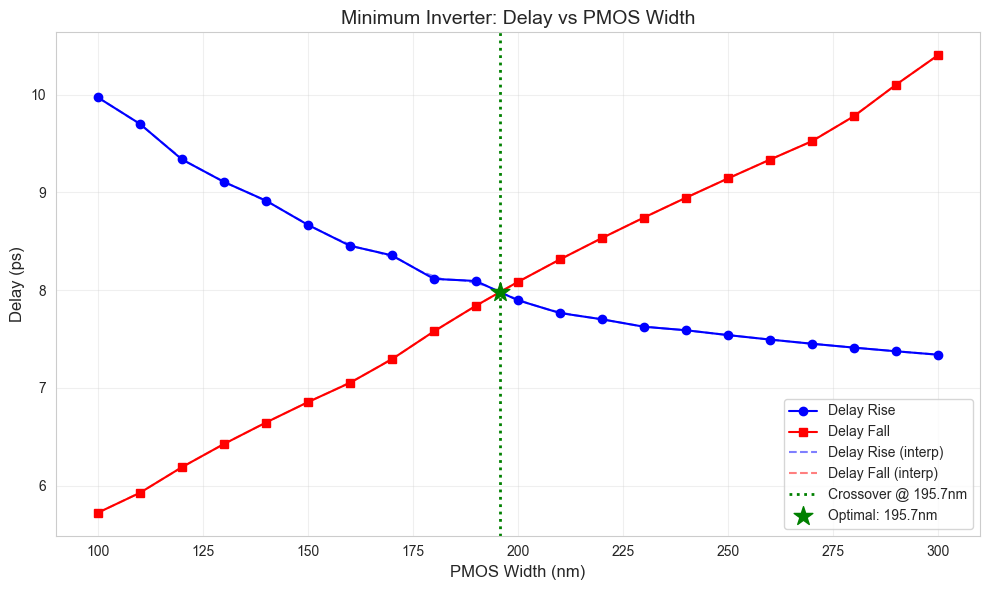


Plot saved to: output\project-01\figs\pmos_sizing_delays.png


In [33]:
# --- 4. PLOT DELAY VS WP ---
# Visualize the delay characteristics

fig, ax = plt.subplots(figsize=(10, 6))

# Plot measured points
ax.plot(df_pmos["wp_nm"], df_pmos["delay_rise_s"] * 1e12, "o-",
        label="Delay Rise", color="blue", markersize=6)
ax.plot(df_pmos["wp_nm"], df_pmos["delay_fall_s"] * 1e12, "s-",
        label="Delay Fall", color="red", markersize=6)

# Plot interpolated lines
ax.plot(wp_fine, delay_rise_interp * 1e12, "--",
        label="Delay Rise (interp)", color="blue", alpha=0.5)
ax.plot(wp_fine, delay_fall_interp * 1e12, "--",
        label="Delay Fall (interp)", color="red", alpha=0.5)

# Mark crossover point
if wp_crossover is not None:
    ax.axvline(x=wp_crossover, color="green", linestyle=":", linewidth=2,
               label=f"Crossover @ {wp_crossover:.1f}nm")
    ax.scatter([wp_crossover], [delay_crossover * 1e12],
               color="green", s=200, zorder=5, marker="*",
               label=f"Optimal: {wp_crossover:.1f}nm")

ax.set_xlabel("PMOS Width (nm)", fontsize=12)
ax.set_ylabel("Delay (ps)", fontsize=12)
ax.set_title("Minimum Inverter: Delay vs PMOS Width", fontsize=14)
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_FIG_FOLDER / "pmos_sizing_delays.png", dpi=300)
plt.show()

print(f"\nPlot saved to: {OUTPUT_FIG_FOLDER / "pmos_sizing_delays.png"}")

## Step 02: Model Calibration - Extract Gamma and Tau0

In this step we extract the model parameters needed for the energy-delay optimization:
- **gamma_delay**: Ratio of drain capacitance to input capacitance (γ = C_d / C_in)
- **gamma_energy**: Related to energy scaling factor
- **tau0**: Intrinsic delay of minimum-sized inverter
- **Cin0**: Input capacitance of minimum-sized inverter

The approach uses two simulations:
1. **inverter_Cin.asc**: Measures input capacitance at different scaling factors
2. **inverter_Cd.asc**: Measures total load capacitance (C_d + C_in)

By comparing energies at different sizes, we can extract C_d and C_in.

In [ ]:
# --- 1. RUN gamma_E SIMULATIONS ---
# 2a. Run C_in simulation (input capacitance measurement)
# 2b. Run C_d simulation (drain capacitance measurement)

# Use wp from Step 01 (rounded to nearest 5nm for LTspice compatibility)
print(f"Using wp = {wp_rounded} nm (rounded from {wp_crossover:.1f} nm)")

# Run C_in simulation
print("\n[2a] Running C_in simulation...")
netlist_cin = SpiceEditor(PROJECT_SIM_FOLDER / "02-gamma_E" / "inverter_Cin.asc")
netlist_cin.set_parameter("wp", f"{wp_rounded}n")
_, log_cin = runner.run_now(netlist_cin)
print("C_in simulation complete.")

# Run C_d simulation
print("\n[2b] Running C_d simulation...")
netlist_cd = SpiceEditor(PROJECT_SIM_FOLDER / "02-gamma_E" / "inverter_Cd.asc")
netlist_cd.set_parameter("wp", f"{wp_rounded}n")
_, log_cd = runner.run_now(netlist_cd)
print("C_d simulation complete.")

Using wp = 195.0 nm (rounded from 195.7 nm)

[2a] Running C_in simulation...
C_in simulation complete.

[2b] Running C_d simulation...
C_d simulation complete.


In [35]:
# --- STEP 02: EXTRACT MEASUREMENTS ---
# Parse simulation results and calculate capacitances

# Parse C_in simulation results
data_cin = LTSpiceLogReader(log_cin.as_posix()) # pyright: ignore[reportOptionalMemberAccess]
S_values = np.arange(1, 10.25, 0.25)[:data_cin.step_count]
energy_cin = np.array(data_cin["energy"])  # Energy values in joules

# Parse C_d simulation results
data_cd = LTSpiceLogReader(log_cd.as_posix()) # pyright: ignore[reportOptionalMemberAccess]
energy_cd = np.array(data_cd["energy"])  # Energy values in joules

# Calculate capacitances from energy: E = 0.5 * C * Vdd^2 => C = 2E / Vdd^2
C_total_cin = 2 * energy_cin / (Vdd ** 2)  # Total C at each S for C_in sim
C_total_cd = 2 * energy_cd / (Vdd ** 2)   # Total C at each S for C_d sim

# Build DataFrame
df_calib = pd.DataFrame({
    "S": S_values,
    "energy_cin_J": energy_cin,
    "C_total_cin_F": C_total_cin,
    "energy_cd_J": energy_cd,
    "C_total_cd_F": C_total_cd
})

print(f"Loaded {len(df_calib)} simulation points for S = {S_values[0]:.2f} to {S_values[-1]:.2f}")
print(f"Energy C_in range: {energy_cin.min():.2e} to {energy_cin.max():.2e} J")
print(f"Energy C_d range: {energy_cd.min():.2e} to {energy_cd.max():.2e} J")
df_calib.filter(items=["S", "energy_cin_J", "C_total_cin_F", "energy_cd_J", "C_total_cd_F"])

Loaded 37 simulation points for S = 1.00 to 10.00
Energy C_in range: 1.20e-15 to 6.60e-15 J
Energy C_d range: 4.93e-16 to 4.90e-15 J


,S,energy_cin_J,C_total_cin_F,energy_cd_J,C_total_cd_F
0,1.00,1.202870e-15,2.405740e-15,4.934680e-16,9.869360e-16
1,1.25,1.353430e-15,2.706860e-15,6.121810e-16,1.224362e-15
2,1.50,1.497130e-15,2.994260e-15,7.378810e-16,1.475762e-15
3,1.75,1.636310e-15,3.272620e-15,8.759680e-16,1.751936e-15
4,2.00,1.781610e-15,3.563220e-15,9.870680e-16,1.974136e-15
5,2.25,1.927030e-15,3.854060e-15,1.112550e-15,2.225100e-15
6,2.50,2.069480e-15,4.138960e-15,1.238110e-15,2.476220e-15
7,2.75,2.217890e-15,4.435780e-15,1.363740e-15,2.727480e-15
8,3.00,2.366040e-15,4.732080e-15,1.489430e-15,2.978860e-15
9,3.25,2.511400e-15,5.022800e-15,1.603020e-15,3.206040e-15


In [36]:
# --- STEP 02: CALCULATE GAMMA_DELAY AND CIN0 ---
# Extract C_in and C_d from measurements

# For inverter_Cin.asc: Two inverters in parallel
# Total C = S * C_d + C_in + S * C_in = S * (C_d + C_in) + C_in
# At S=1: C_total = C_d + 2*C_in
# For S>>1: C_total / S -> C_d + C_in

# For inverter_Cd.asc: Single scaled inverter
# Total C = S * C_d + S * C_in = S * (C_d + C_in)
# At S=1: C_total = C_d + C_in
# For S>>1: C_total / S -> C_d + C_in

# Calculate C_in and C_d from C_d simulation (simpler case)
# C_total_cd = S * (C_d + C_in)
# C_per_S = C_total_cd / S = C_d + C_in = C_total_1 (at S=1)

# Use linear regression to find C_d and C_in
# C_total = S * C_d + S * C_in = S * (C_d + C_in)
# Slope = C_d + C_in, Intercept should be 0

from scipy import stats

# Linear fit: C_total_cd = S * (C_d + C_in)
slope_cd, intercept_cd, r_value, p_value, std_err = stats.linregress(
    df_calib["S"], df_calib["C_total_cd_F"]
)

# C_d + C_in = slope
C_d_plus_Cin = slope_cd

# For C_in simulation, we need to separate the contributions
# From C_d simulation at S=1, get C_d + C_in
C_d_plus_Cin_S1 = df_calib[df_calib["S"] == 1.0]["C_total_cd_F"].values[0]

# From C_in simulation:
# C_total_cin = S * C_d + C_in + S * C_in = S * C_d + C_in * (S + 1)
# At S=1: C_total_cin = C_d + 2*C_in
C_total_cin_S1 = df_calib[df_calib["S"] == 1.0]["C_total_cin_F"].values[0]

# Solve the system:
# C_d + C_in = C_d_plus_Cin_S1
# C_d + 2*C_in = C_total_cin_S1

Cin0 = C_total_cin_S1 - C_d_plus_Cin_S1  # C_in at S=1
Cd = C_d_plus_Cin_S1 - Cin0  # Drain capacitance

# Calculate gamma_delay
gamma_delay = Cd / Cin0

print("=" * 60)
print("CALIBRATION RESULTS")
print("=" * 60)
print(f"Cin0 (C_in at S=1):     {Cin0 * 1e12:.4f} fF")
print(f"C_d (drain capacitance): {Cd * 1e12:.4f} fF")
print(f"C_d + C_in:             {C_d_plus_Cin_S1 * 1e12:.4f} fF")
print(f"gamma_delay (Cd/Cin):  {gamma_delay:.4f}")
print("=" * 60)

CALIBRATION RESULTS
Cin0 (C_in at S=1):     0.0014 fF
C_d (drain capacitance): -0.0004 fF
C_d + C_in:             0.0010 fF
gamma_delay (Cd/Cin):  -0.3044


In [37]:
# --- STEP 02: CALCULATE TAU0 ---
# Run delay simulation for minimum inverter to get tau0

print("\n[2c] Running delay simulation for tau0...")
netlist_tau = SpiceEditor(PROJECT_SIM_FOLDER / "03-gamma_D" / "inverter_gamma_D.asc")
netlist_tau.set_parameter("wp", f"{wp_rounded}n")
_, log_tau = runner.run_now(netlist_tau)
print("Delay simulation complete.")

# Extract delay measurements
data_tau = LTSpiceLogReader(log_tau.as_posix()) # pyright: ignore[reportOptionalMemberAccess]
delay_values = np.array(data_tau["delay"])  # Delay values in seconds

# Build DataFrame for delay
df_tau = pd.DataFrame({
    "S": S_values[:len(delay_values)],
    "delay_s": delay_values
})

print("\nDelay measurements (first 5 points):")
print(df_tau.head())


[2c] Running delay simulation for tau0...
Delay simulation complete.

Delay measurements (first 5 points):
      S       delay_s
0  1.00  2.074940e-11
1  1.25  2.365020e-11
2  1.50  2.627320e-11
3  1.75  2.942360e-11
4  2.00  3.307720e-11


In [ ]:
# --- STEP 02: EXTRACT TAU0 FROM DELAY MEASUREMENTS ---
# The delay model: tau = tau0 * (1 + gamma * (S - 1))
# At S=1: tau = tau0

# Get delay at S=1
tau0 = df_tau[df_tau["S"] == 1.0]["delay_s"].values[0]

# Verify with regression: tau = tau0 * (1 + gamma * (S - 1))
# tau / tau0 - 1 = gamma * (S - 1)
# Let y = tau / tau0 - 1, x = S - 1, then y = gamma * x

df_tau["normalized_delay"] = df_tau["delay_s"] / tau0
df_tau["x"] = df_tau["S"] - 1
df_tau["y"] = df_tau["normalized_delay"] - 1

# Linear fit to verify gamma
slope_gamma, intercept_gamma, r_value, p_value, std_err = stats.linregress(
    df_tau["x"], df_tau["y"]
)

print("=" * 60)
print("TAU0 EXTRACTION RESULTS")
print("=" * 60)
print(f"tau0 (delay at S=1):    {tau0 * 1e12:.4f} ps")
print(f"gamma (from delay):    {slope_gamma:.4f}")
print(f"R-squared:             {r_value**2:.4f}") # pyright: ignore[reportOperatorIssue]
print("=" * 60)

TAU0 EXTRACTION RESULTS
tau0 (delay at S=1):    20.7494 ps
gamma (from delay):    0.5758
R-squared:             0.9999


In [39]:
# --- STEP 02: CALCULATE GAMMA_ENERGY ---
# Energy model: E = 0.5 * C_in * Vdd^2 * (1 + gamma * (S - 1))
# At S=1: E = 0.5 * C_in * Vdd^2
# For S>1: E = E1 * (1 + gamma_energy * (S - 1))

# Get energy at S=1
E_S1 = df_calib[df_calib["S"] == 1.0]["energy_cd_J"].values[0]

# Normalize energy
df_calib["normalized_energy"] = df_calib["energy_cd_J"] / E_S1
df_calib["x"] = df_calib["S"] - 1
df_calib["y"] = df_calib["normalized_energy"] - 1

# Linear fit
slope_energy, _, r_energy, _, _ = stats.linregress(
    df_calib["x"], df_calib["y"]
)

gamma_energy = slope_energy

print("=" * 60)
print("GAMMA_ENERGY EXTRACTION RESULTS")
print("=" * 60)
print(f"gamma_energy:           {gamma_energy:.4f}")
print(f"R-squared:              {r_energy**2:.4f}")
print("=" * 60)

GAMMA_ENERGY EXTRACTION RESULTS
gamma_energy:           0.9913
R-squared:              1.0000


In [40]:
# --- STEP 02: SUMMARY OF CALIBRATED PARAMETERS ---

print("\n" + "=" * 60)
print("CALIBRATED MODEL PARAMETERS (Step 02 Summary)")
print("=" * 60)
print(f"wp (minimum PMOS width):   {wp_rounded} nm")
print("wn (minimum NMOS width):   120 nm")
print(f"Cin0 (input capacitance):  {Cin0 * 1e12:.4f} fF")
print(f"C_d (drain capacitance):   {Cd * 1e12:.4f} fF")
print(f"gamma_delay:               {gamma_delay:.4f}")
print(f"gamma_energy:              {gamma_energy:.4f}")
print(f"tau0:                      {tau0 * 1e12:.4f} ps")
print("=" * 60)

# Store in global variables for next steps
calibration_params = {
    "wp_rounded": wp_rounded,
    "Cin0": Cin0,
    "Cd": Cd,
    "gamma_delay": gamma_delay,
    "gamma_energy": gamma_energy,
    "tau0": tau0
}


CALIBRATED MODEL PARAMETERS (Step 02 Summary)
wp (minimum PMOS width):   195.0 nm
wn (minimum NMOS width):   120 nm
Cin0 (input capacitance):  0.0014 fF
C_d (drain capacitance):   -0.0004 fF
gamma_delay:               -0.3044
gamma_energy:              0.9913
tau0:                      20.7494 ps


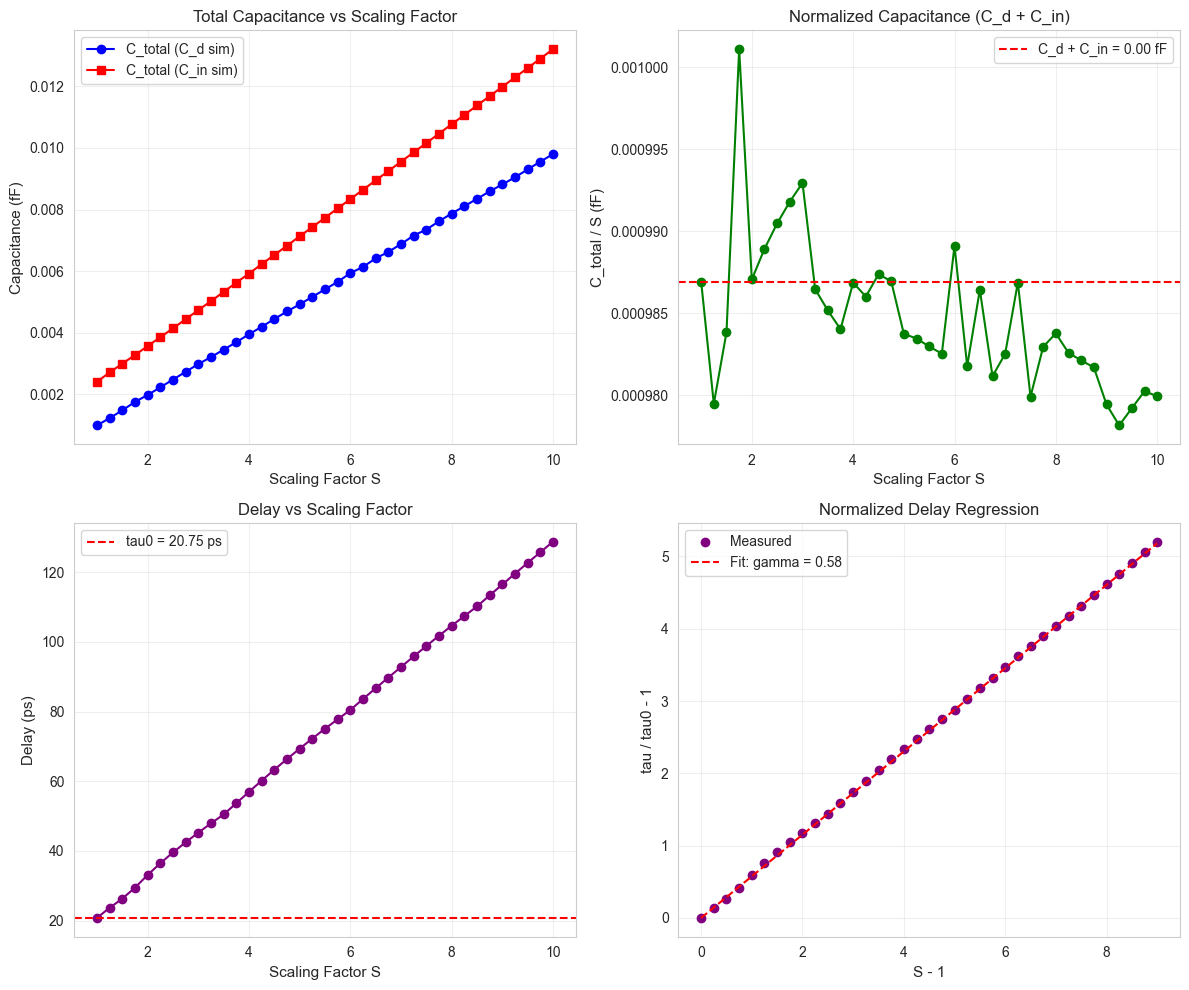


Plot saved to: output\project-01\figs\calibration_results.png


In [41]:
# --- STEP 02: VISUALIZATION ---
# Plot capacitance and delay vs scaling factor

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Capacitance vs S
ax1 = axes[0, 0]
ax1.plot(df_calib["S"], df_calib["C_total_cd_F"] * 1e12, "o-",
         label="C_total (C_d sim)", color="blue")
ax1.plot(df_calib["S"], df_calib["C_total_cin_F"] * 1e12, "s-",
         label="C_total (C_in sim)", color="red")
ax1.set_xlabel("Scaling Factor S", fontsize=11)
ax1.set_ylabel("Capacitance (fF)", fontsize=11)
ax1.set_title("Total Capacitance vs Scaling Factor", fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: C_total/S vs S (should be constant = C_d + C_in)
ax2 = axes[0, 1]
C_per_S = df_calib["C_total_cd_F"] / df_calib["S"]
ax2.plot(df_calib["S"], C_per_S * 1e12, "o-", color="green")
ax2.axhline(y=C_d_plus_Cin_S1 * 1e12, color="red", linestyle="--",
            label=f"C_d + C_in = {C_d_plus_Cin_S1 * 1e12:.2f} fF")
ax2.set_xlabel("Scaling Factor S", fontsize=11)
ax2.set_ylabel("C_total / S (fF)", fontsize=11)
ax2.set_title("Normalized Capacitance (C_d + C_in)", fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Delay vs S
ax3 = axes[1, 0]
ax3.plot(df_tau["S"], df_tau["delay_s"] * 1e12, "o-", color="purple")
ax3.axhline(y=tau0 * 1e12, color="red", linestyle="--",
            label=f"tau0 = {tau0 * 1e12:.2f} ps")
ax3.set_xlabel("Scaling Factor S", fontsize=11)
ax3.set_ylabel("Delay (ps)", fontsize=11)
ax3.set_title("Delay vs Scaling Factor", fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Normalized Delay vs (S-1)
ax4 = axes[1, 1]
ax4.plot(df_tau["x"], df_tau["y"], "o", color="purple", label="Measured")
x_fit = np.linspace(0, df_tau["x"].max(), 100)
y_fit = slope_gamma * x_fit
ax4.plot(x_fit, y_fit, "r--", label=f"Fit: gamma = {slope_gamma:.2f}")
ax4.set_xlabel("S - 1", fontsize=11)
ax4.set_ylabel("tau / tau0 - 1", fontsize=11)
ax4.set_title("Normalized Delay Regression", fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_FIG_FOLDER / "calibration_results.png", dpi=300)
plt.show()

print(f"\nPlot saved to: {OUTPUT_FIG_FOLDER / "calibration_results.png"}")